# Speaker-Level Test of Conversational Styles

The utterance-level analysis (see `03_fix_scaling_and_backchannel_autopsy.ipynb`, Part E) showed the bimodal
"two styles" result was an artifact of **backchannel utterances** (`yeah` / `uh-huh` / `um-hum`): once
those are removed, PC0 is unimodal. But a conversational *style* is a property of a **speaker**, not a
one-word utterance — so the proper test is whether **speakers** cluster into two groups.

Here we aggregate each speaker's substantive utterances to a feature profile, run PCA across speakers,
and ask: is the speaker distribution bimodal (two styles) or a single continuum?

**Speaker = caller, not conversation side.** The filename gives a conversation *side*
(`200/sw2001A-U0002.wav` -> `sw2001A` = conversation 2001 + A/B side), but a single caller takes part
in ~9 calls, appearing as a different side each time. Grouping by side would pseudo-replicate every
speaker ~9x and inflate n in every test below. We therefore map each side to its `caller_no` via
`tables/call_con_tab.csv` and aggregate at true **caller** level, pooling each person's utterances
across all their calls.

In [1]:
import pandas as pd, numpy as np, string
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.stats import skew, gaussian_kde, ttest_ind
from scipy.signal import find_peaks
import seaborn as sns, matplotlib.pyplot as plt

## Step 1 — Load utterances & roll up conversation sides to callers

In [2]:
df = pd.read_csv("../utterances_v2/paper_aligned_standardized_PCA.csv")

# --- speaker roll-up: collapse conversation SIDES to the actual CALLER ----------
# "sw####A/B" is a conversation SIDE, not a person. Each caller takes part in ~9
# calls, so grouping by side pseudo-replicates every speaker ~9x and inflates n in
# every downstream test (PCA point count, BIC/silhouette, the gender Welch t).
# Map (conversation_no, side) -> caller_no with the corpus table and use the
# caller as the speaker, pooling all of their utterances across calls.
df["side"] = df["Utterance File Name"].str.extract(r"(sw\d+[AB])")
_cc = pd.read_csv("../tables/call_con_tab.csv", header=None,
                  names=["conv", "conv_side", "caller", "phone", "length",
                         "ivi", "remarks", "active"])
_cc["conv_side"] = _cc["conv_side"].str.strip().str.strip('"')
_side2caller = {f"sw{int(c):04d}{s}": int(k)
                for c, s, k in zip(_cc["conv"], _cc["conv_side"], _cc["caller"])}
df["speaker"] = df["side"].map(_side2caller)   # speaker == caller_no (the person)
_unmapped = int(df["speaker"].isna().sum())
df = df.dropna(subset=["speaker"]).copy()
df["speaker"] = df["speaker"].astype(int)
# -------------------------------------------------------------------------------

feature_cols = ["token_count", "loudness mean", "loudness std", "loudness range", "Turn Gap",
                "word_rate", "syllable_rate", "Pronouns per Second",
                "Repetitions In Current Utterance", "Repetitions In Previous Utterance",
                "Filler Words per Second"]
print(f"Utterances: {len(df)} | conversation sides: {df['side'].nunique()} "
      f"| distinct callers (speakers): {df['speaker'].nunique()} | unmapped utts dropped: {_unmapped}")

Utterances: 212210 | conversation sides: 3988 | distinct callers (speakers): 493 | unmapped utts dropped: 0


## Step 2 — Flag backchannels & aggregate each speaker to a profile

In [3]:
BC = {"yeah", "yea", "yep", "yup", "yes", "ya", "yah", "uh-huh", "uhhuh", "huh-uh", "um-hum",
      "umhum", "mm-hmm", "mm-hm", "mmhm", "mhm", "m-hm", "mm", "mmm", "hm", "hmm", "hmmm",
      "hum", "huh", "uh", "um", "er", "erm", "ah", "oh", "ooh", "aw", "okay", "ok", "right",
      "sure", "wow", "gosh"}

def is_backchannel(t):
    toks = [w.strip(string.punctuation).lower() for w in str(t).split()]
    toks = [w for w in toks if w]
    return len(toks) > 0 and all(w in BC for w in toks)

df["is_bc"] = df["Transcript"].apply(is_backchannel)

# per-speaker mean of features over SUBSTANTIVE utterances; plus backchannel rate over ALL utterances
sub = df[~df["is_bc"]]
spk = sub.groupby("speaker")[feature_cols].mean()
spk["n_sub"] = sub.groupby("speaker").size()
spk["bc_rate"] = df.groupby("speaker")["is_bc"].mean()
# one demographic row per speaker
for d in ["Gender", "Region", "Generation", "Education", "Year Born"]:
    spk[d] = df.groupby("speaker")[d].first()

print(f"Substantive utterances/speaker: median {int(spk['n_sub'].median())}, "
      f"min {spk['n_sub'].min()}, max {spk['n_sub'].max()}")
MIN = 20  # require enough utterances for a stable per-speaker mean
spk = spk[spk["n_sub"] >= MIN].copy()
print(f"Speakers retained (>= {MIN} substantive utterances): {len(spk)}")

Substantive utterances/speaker: median 236, min 11, max 1576
Speakers retained (>= 20 substantive utterances): 487


## Step 3 — PCA across speakers (standardized per-speaker means)

In [4]:
Xs = StandardScaler().fit_transform(spk[feature_cols].values)
pca = PCA(n_components=len(feature_cols))
scores = pca.fit_transform(Xs)
spk["pc0"] = scores[:, 0]
pc0 = scores[:, 0]
print(f"PC0 explained variance: {pca.explained_variance_ratio_[0]*100:.2f}%")
load = (pd.DataFrame({"Feature": feature_cols, "Magnitude": pca.components_[0]})
        .assign(a=lambda d: d.Magnitude.abs()).sort_values("a", ascending=False))
print("\nPC0 loadings:")
for _, r in load.iterrows():
    print(f"  {r.Magnitude:+.4f}  {r.Feature}")

PC0 explained variance: 42.49%

PC0 loadings:
  +0.4155  token_count
  +0.4104  Repetitions In Current Utterance
  +0.3988  word_rate
  +0.3896  syllable_rate
  +0.3383  Repetitions In Previous Utterance
  +0.3036  Pronouns per Second
  +0.2025  Filler Words per Second
  +0.1817  loudness mean
  +0.1790  loudness range
  +0.1631  loudness std
  +0.0943  Turn Gap


## Step 4 — Histogram of speaker PC0 & scree

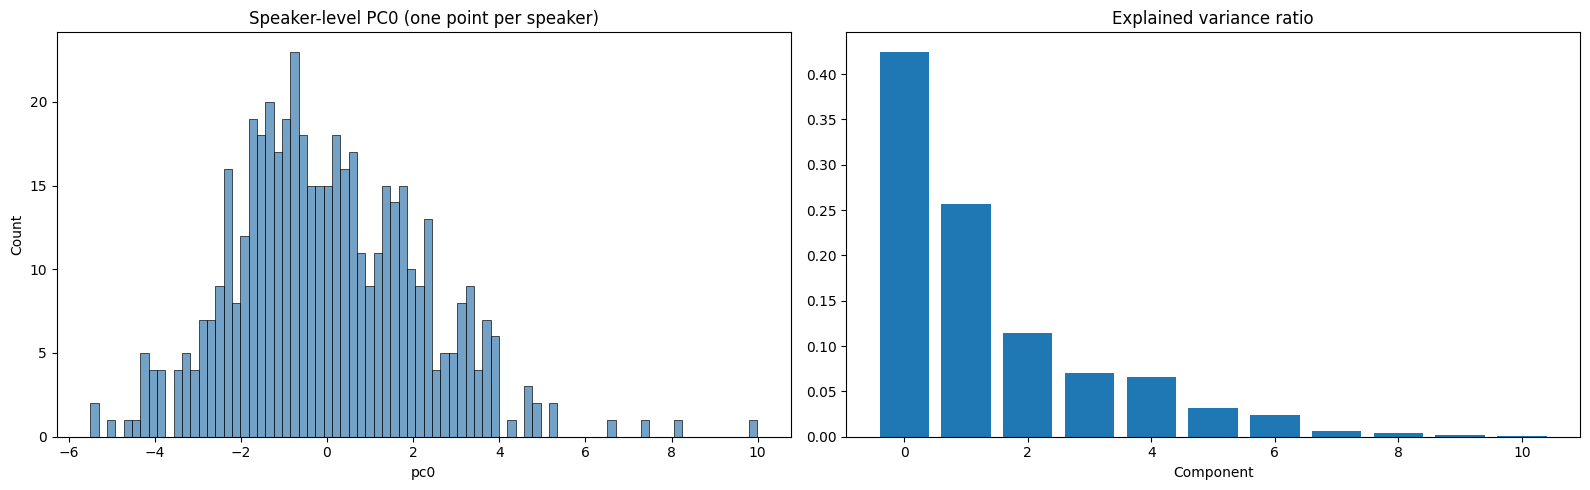

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(pc0, bins=80, ax=ax[0], color="steelblue")
ax[0].set_title("Speaker-level PC0 (one point per speaker)"); ax[0].set_xlabel("pc0")
ax[1].bar(range(len(feature_cols)), pca.explained_variance_ratio_)
ax[1].set_title("Explained variance ratio"); ax[1].set_xlabel("Component")
plt.tight_layout(); plt.show()

## Step 5 — Unimodal or bimodal? (KDE mode count + skew)

In [6]:
print(f"PC0 skew = {skew(pc0):+.3f}")
grid = np.linspace(pc0.min(), pc0.max(), 2000)
for bw in [0.15, 0.25, 0.40, 0.60]:
    d = gaussian_kde(pc0, bw_method=bw)(grid)
    pk, _ = find_peaks(d, prominence=d.max() * 0.01)
    print(f"  KDE bw={bw}: {len(pk)} mode(s) at {np.round(grid[pk], 2)}")

PC0 skew = +0.488
  KDE bw=0.15: 3 mode(s) at [-0.86  1.5   3.21]
  KDE bw=0.25: 1 mode(s) at [-0.9]
  KDE bw=0.4: 1 mode(s) at [-0.7]
  KDE bw=0.6: 1 mode(s) at [-0.45]


## Step 6 — Silhouette & BIC

Watch for the trap: silhouette can favor k>=2 by slicing a single hump, and BIC can prefer 2 Gaussians
just to model **skew** (not a second mode). Read these against the KDE in Step 5 and the size of the
BIC improvement.

In [7]:
X1 = pc0.reshape(-1, 1)
sil = {k: round(silhouette_score(X1, GaussianMixture(k, random_state=0).fit(X1).predict(X1),
                                 random_state=0), 3) for k in range(2, 8)}
bic = {k: round(GaussianMixture(k, random_state=0).fit(X1).bic(X1)) for k in range(1, 8)}
print("Silhouette:", sil, "-> best k =", max(sil, key=sil.get))
print("BIC       :", bic)
d12 = bic[2] - bic[1]
print(f"\nBIC(k=2) - BIC(k=1) = {d12:+d}  (compare: utterance-level backchannel split was ~ -53,000)")

Silhouette: {2: 0.575, 3: 0.506, 4: 0.493, 5: 0.521, 6: 0.535, 7: 0.538} -> best k = 2
BIC       : {1: 2145, 2: 2155, 3: 2173, 4: 2181, 5: 2193, 6: 2208, 7: 2225}

BIC(k=2) - BIC(k=1) = +10  (compare: utterance-level backchannel split was ~ -53,000)


## Step 7 — If forced to k=2, what separates the two groups?

In [8]:
g2 = GaussianMixture(n_components=2, random_state=0).fit(X1)
spk["lab"] = g2.predict(X1)
order = spk.groupby("lab")["word_rate"].mean().sort_values().index
print("Forced k=2 speaker groups:")
for L in order:
    g = spk[spk["lab"] == L]
    print(f"  group {L}: n={len(g):>4d} | token_count={g['token_count'].mean():5.2f} | "
          f"word_rate={g['word_rate'].mean():.2f} | Turn Gap={g['Turn Gap'].mean():+.3f} | "
          f"bc_rate={g['bc_rate'].mean():.2f}")
print(f"\nPC0 correlation with backchannel rate: {np.corrcoef(pc0, spk['bc_rate'])[0,1]:+.3f}")
print(f"PC0 correlation with #utterances:      {np.corrcoef(pc0, spk['n_sub'])[0,1]:+.3f}")

Forced k=2 speaker groups:
  group 1: n= 321 | token_count=14.15 | word_rate=2.48 | Turn Gap=-0.417 | bc_rate=0.25
  group 0: n= 166 | token_count=19.99 | word_rate=2.89 | Turn Gap=-0.310 | bc_rate=0.23

PC0 correlation with backchannel rate: -0.079
PC0 correlation with #utterances:      +0.026


## Step 8 — Demographics along the PC0 continuum (RQ3, done as a continuum)

Since PC0 is continuous, we compare its *mean by demographic group* rather than forcing clusters.
Demographics were **not** used to build PC0, so a t-test of PC0 across, e.g., gender is legitimate
(not double-dipping).

In [9]:
for dcol in ["Gender", "Generation", "Region", "Education"]:
    print(f"\nMean speaker PC0 by {dcol}:")
    g = spk.groupby(dcol)["pc0"].agg(["mean", "count"]).sort_values("mean")
    print(g.round(3).to_string())

# legitimate test: PC0 difference between the two largest gender groups
gtop = spk["Gender"].value_counts().head(2).index.tolist()
a = spk[spk["Gender"] == gtop[0]]["pc0"]; b = spk[spk["Gender"] == gtop[1]]["pc0"]
t, p = ttest_ind(a, b, equal_var=False)
dd = (a.mean() - b.mean()) / np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
print(f"\nPC0 {gtop[0]} vs {gtop[1]}: Welch p={p:.2e}, Cohen d={dd:+.3f}")


Mean speaker PC0 by Gender:
         mean  count
Gender              
female -0.522    232
male    0.475    255

Mean speaker PC0 by Generation:
               mean  count
Generation                
GI           -1.841      2
Generation_X -0.202     83
Silent       -0.173    116
Baby_Boomer   0.142    286

Mean speaker PC0 by Region:
                mean  count
Region                     
mixed         -0.309     26
western       -0.307     76
south_midland -0.255    147
northern       0.062     69
southern       0.310     52
north_midland  0.368     69
new_england    0.453     18
nyc            0.500     30

Mean speaker PC0 by Education:
            mean  count
Education              
1         -0.377     37
2         -0.202    278
9          0.162      4
3          0.364    162
0          1.767      6

PC0 male vs female: Welch p=2.33e-07, Cohen d=+0.475


## Step 9 — Conclusion

If KDE shows a single mode and the BIC(k=2) improvement is tiny relative to the utterance-level
backchannel split, then **speakers also do not separate into two discrete styles** — PC0 is a single
continuous "verbal intensity / productivity" axis (talkative + faster + more repetitive speakers at
one end, terse speakers at the other), with Turn Gap again a weak contributor.

This is consistent across utterance-level and speaker-level analyses and supports reframing the result
as **a continuum between Tannen's poles**, not two discrete populations — and any demographic effects
should be reported as shifts *along* that continuum.